In [9]:
import os
print(os.listdir("/kaggle/input/datasets/sandiyaboby/ooooooo"))

['CICIDS2017.csv']


In [10]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
# Ensure the path matches your Kaggle input directory
FILE_PATH = "/kaggle/input/datasets/sandiyaboby/ooooooo/CICIDS2017.csv"
df = pd.read_csv(FILE_PATH)

# 2. Strip whitespace from column names (Critical for indexing)
df.columns = df.columns.str.strip()

# 3. Duplicate Purge (Handles the 12,598 structural corruptions)
df.drop_duplicates(inplace=True)

# 4. Handling Infinity (The 81 & 27 cases)
# Convert 'inf' to 'NaN' first
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 5. Median Imputation (Preserves data volume and stability)
# Only apply to numeric columns to avoid errors
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 6. Constant Feature Filter (Remove Zero Variance columns)
# This removes 'Bwd PSH Flags' and other 'dead' columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)

# 7. Save Clean Data
df.to_csv('CICIDS2017_cleaned_step1.csv', index=False)

print("Step 1 Complete.")
print(f"Total rows remaining: {df.shape[0]}")
print(f"Total columns remaining: {df.shape[1]}")
print("Cleaned data saved as: CICIDS2017_cleaned_step1.csv")

Step 1 Complete.
Total rows remaining: 44063
Total columns remaining: 70
Cleaned data saved as: CICIDS2017_cleaned_step1.csv


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# 1. Load the data saved from Step 1
df = pd.read_csv('CICIDS2017_cleaned_step1.csv')

# 2. Log Transformation (log1p)
# We apply this to features with massive ranges to prevent Gradient Explosion.
# log1p is used because log(1+x) handles zero values safely.
skewed_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 
               'Total Length of Fwd Packets', 'Total Length of Bwd Packets']

for col in skewed_cols:
    if col in df.columns:
        df[col] = np.log1p(df[col])

# 3. Separate Features and Label
# We must scale features (X) but leave the Label (y) as is.
X = df.drop('Label', axis=1)
y = df['Label']

# 4. Robust Scaling
# Uses IQR to scale data, ensuring 11,000+ outliers don't shrink the normal data.
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 5. Convert back to DataFrame to save with column names
df_refined = pd.DataFrame(X_scaled, columns=X.columns)
df_refined['Label'] = y.values  # Add the labels back

# 6. Save the Refined Data
df_refined.to_csv('CICIDS2017_refined_step2.csv', index=False)

print("Step 2 Complete.")
print(f"Features Stabilized: {len(X.columns)}")
print("Refined data saved as: CICIDS2017_refined_step2.csv")

Step 2 Complete.
Features Stabilized: 69
Refined data saved as: CICIDS2017_refined_step2.csv


In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Load the refined data you just saved in Step 2
df = pd.read_csv('CICIDS2017_refined_step2.csv')

# 2. Encode the Labels
# Even though we are doing RF, we need numeric labels for the final LSTM
le = LabelEncoder()
X = df.drop('Label', axis=1)
y = le.fit_transform(df['Label'])

# 3. Random Forest Training
print("Training Random Forest to extract feature importance...")
# n_jobs=-1 uses all CPU cores to speed up the training
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X, y)

# 4. Get Importance and Rank them
importances = rf_selector.feature_importances_
feature_names = X.columns
rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. Select the Top 30 Features
top_30_rf_features = rf_importance_df.head(30)['Feature'].tolist()

print("\nTop 10 Features Selected by Random Forest:")
print(rf_importance_df.head(10))

# 6. Save the reduced dataset for the next step (SMOTE)
X_selected = X[top_30_rf_features]
df_rf_selected = X_selected.copy()
df_rf_selected['Label'] = y

df_rf_selected.to_csv('CICIDS2017_rf_selected_step3.csv', index=False)

print("\nStep 3 Complete.")
print(f"Dataset narrowed down to {len(top_30_rf_features)} features.")
print("Feature-selected data saved as: CICIDS2017_rf_selected_step3.csv")

Training Random Forest to extract feature importance...

Top 10 Features Selected by Random Forest:
                        Feature  Importance
39       Packet Length Variance    0.077095
11       Bwd Packet Length Mean    0.055419
51         Avg Bwd Segment Size    0.052527
12        Bwd Packet Length Std    0.049779
49          Average Packet Size    0.046093
38            Packet Length Std    0.041444
36            Max Packet Length    0.035315
58      Init_Win_bytes_backward    0.031973
37           Packet Length Mean    0.031560
4   Total Length of Bwd Packets    0.029951

Step 3 Complete.
Dataset narrowed down to 30 features.
Feature-selected data saved as: CICIDS2017_rf_selected_step3.csv


In [13]:
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# 1. Load the RF-selected data from Step 3
df = pd.read_csv('CICIDS2017_rf_selected_step3.csv')

X = df.drop('Label', axis=1)
y = df['Label']

# 2. Apply SMOTE
# This balances all classes to match the majority class count
print("Applying SMOTE to balance the RF-selected features...")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 3. Check the new distribution
print("\nClass distribution after SMOTE:")
unique, counts = np.unique(y_res, return_counts=True)
print(dict(zip(unique, counts)))

# 4. Save the Balanced Data
df_balanced = pd.DataFrame(X_res, columns=X.columns)
df_balanced['Label'] = y_res
df_balanced.to_csv('CICIDS2017_rf_balanced_step4.csv', index=False)

print("\nStep 4 Complete.")
print(f"Total samples after balancing: {len(df_balanced)}")

Applying SMOTE to balance the RF-selected features...

Class distribution after SMOTE:
{np.int64(0): np.int64(21699), np.int64(1): np.int64(21699), np.int64(2): np.int64(21699), np.int64(3): np.int64(21699), np.int64(4): np.int64(21699), np.int64(5): np.int64(21699), np.int64(6): np.int64(21699)}

Step 4 Complete.
Total samples after balancing: 151893


In [14]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# 1. Ensure X_res and y_res are ready from the SMOTE step
# Split into Training and Testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# 2. Reshape to 3D: [Samples, Time Steps, Features]
X_train_3D = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_3D = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"Data Reshaped: Training {X_train_3D.shape}, Testing {X_test_3D.shape}")

# 3. Define the LSTM Architecture
model = Sequential([
    LSTM(64, input_shape=(X_train_3D.shape[1], X_train_3D.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(len(np.unique(y_res)), activation='softmax')
])

# 4. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 6. Train
print("Starting LSTM Training...")
history = model.fit(
    X_train_3D, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.save('RF_LSTM_Hybrid_Model.h5')

Data Reshaped: Training (121514, 1, 30), Testing (30379, 1, 30)


I0000 00:00:1775893467.537633    1211 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775893467.542752    1211 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting LSTM Training...
Epoch 1/50


I0000 00:00:1775893471.531955    1269 cuda_dnn.cc:529] Loaded cuDNN version 91002


760/760 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7658 - loss: 0.7267 - val_accuracy: 0.9173 - val_loss: 0.2537
Epoch 2/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9061 - loss: 0.2854 - val_accuracy: 0.9229 - val_loss: 0.2344
Epoch 3/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9150 - loss: 0.2545 - val_accuracy: 0.9327 - val_loss: 0.1875
Epoch 4/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9221 - loss: 0.2307 - val_accuracy: 0.9426 - val_loss: 0.1690
Epoch 5/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9292 - loss: 0.2122 - val_accuracy: 0.9419 - val_loss: 0.1713
Epoch 6/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9276 - loss: 0.2140 - val_accuracy: 0.9395 - val_loss: 0.1694
Epoch 7/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9325 - loss: 0.2006 - val_accuracy: 0.9484 - val_loss: 0.1598
Epoch 8/50
760/760 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9340 - loss: 0.1954 - val_accuracy: 0.9466 - val

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- Classification Report (RF + LSTM Hybrid) ---
              precision    recall  f1-score   support

      BENIGN       0.98      0.87      0.92      4339
         Bot       0.84      0.99      0.91      4340
  BruteForce       0.94      1.00      0.97      4340
         DoS       0.99      0.96      0.97      4340
Infiltration       1.00      0.94      0.97      4340
    PortScan       0.98      0.96      0.97      4340
   WebAttack       0.99      0.97      0.98      4340

    accuracy                           0.96     30379
   macro avg       0.96      0.96      0.96     30379
weighted avg       0.96      0.96      0.96     30379



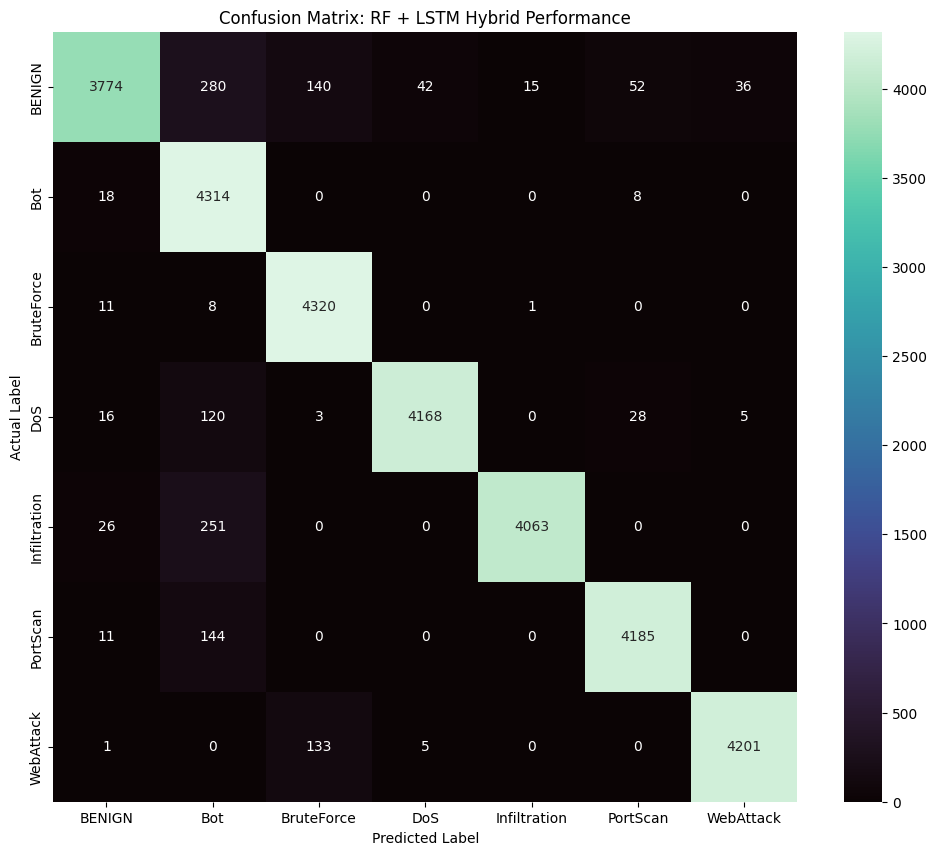

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get Predictions from the test set
y_pred_prob = model.predict(X_test_3D)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for every attack type
print("\n--- Classification Report (RF + LSTM Hybrid) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Visualization: Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix: RF + LSTM Hybrid Performance")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

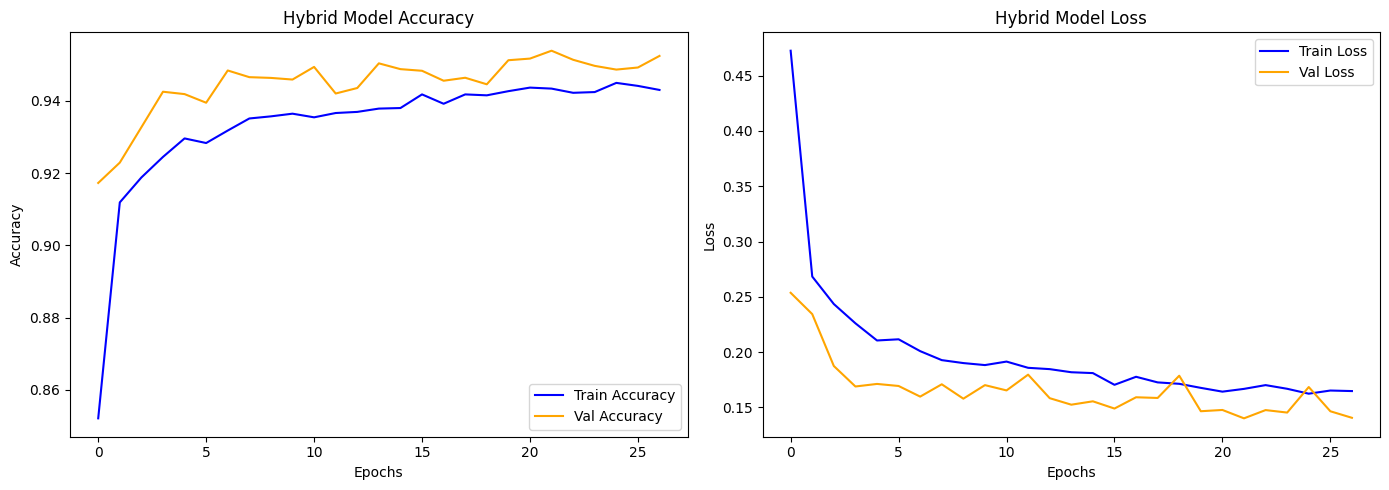

In [16]:
# 4. Plot Training vs Validation Accuracy/Loss
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Hybrid Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Hybrid Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


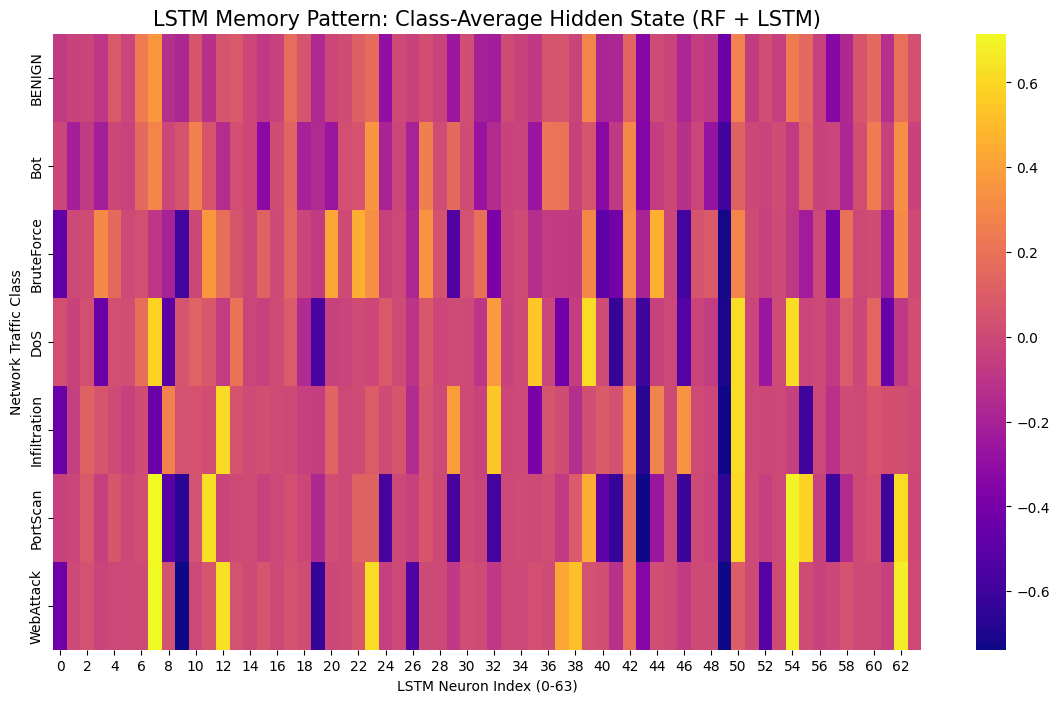

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
import seaborn as sns
import matplotlib.pyplot as plt

# 1. To solve "layer never been called" error:
# We trigger the model's internal tracing by passing a small batch through it
dummy_input = X_test_3D[:1]
_ = model(dummy_input) 

# 2. Now we can safely create the sub-model using the layers
# We use the Input layer from the existing model and the output of the LSTM layer
lstm_layer_model = Model(inputs=model.layers[0].input, 
                         outputs=model.layers[0].output)

# 3. Predict the hidden states
X_sample = X_test_3D[:5000]
y_sample = y_test[:5000]
lstm_states = lstm_layer_model.predict(X_sample)

# Adjust dimensions: LSTM output with return_sequences=True is (Batch, Time, Neurons)
if len(lstm_states.shape) == 3:
    lstm_states = lstm_states[:, 0, :]

# 4. Calculate average hidden state per class
class_avg_states = []
unique_labels = np.unique(y_sample)
valid_classes = []

for label in unique_labels:
    mask = (y_sample == label)
    if np.any(mask):
        avg_state = np.mean(lstm_states[mask], axis=0)
        class_avg_states.append(avg_state)
        valid_classes.append(le.classes_[label])

class_avg_states = np.array(class_avg_states)

# 5. Plot
plt.figure(figsize=(14, 8))
sns.heatmap(class_avg_states, cmap='plasma', yticklabels=valid_classes)
plt.title("LSTM Memory Pattern: Class-Average Hidden State (RF + LSTM)", size=15)
plt.xlabel("LSTM Neuron Index (0-63)")
plt.ylabel("Network Traffic Class")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


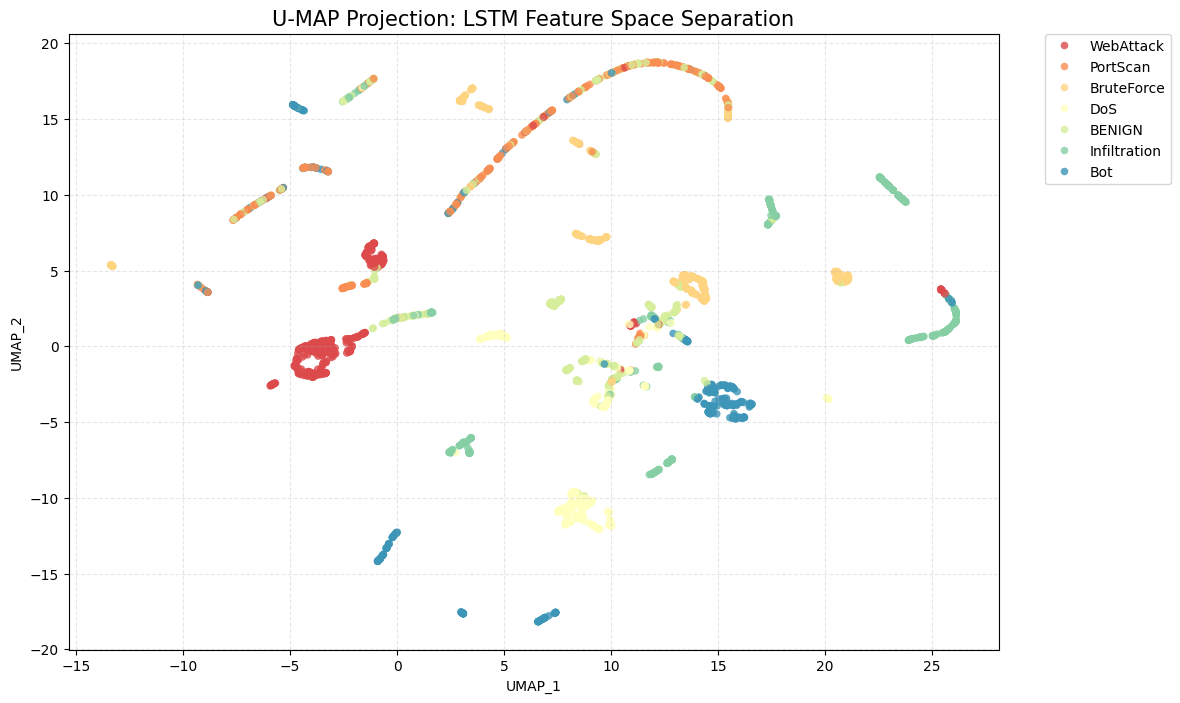

In [18]:
import umap
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Take a balanced subset to keep the plot clean (e.g., 3000 samples)
# We use X_test because it represents "unseen" data
if len(X_test) > 3000:
    indices = np.random.choice(len(X_test), 3000, replace=False)
    X_viz = X_test.iloc[indices]
    y_viz = y_test.iloc[indices]
else:
    X_viz = X_test
    y_viz = y_test

# 2. Initialize and Fit U-MAP
# n_neighbors=15 balances local vs global structure
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_viz)

# 3. Create a DataFrame for Seaborn
df_umap = pd.DataFrame(embedding, columns=['UMAP_1', 'UMAP_2'])
df_umap['Attack Type'] = le.inverse_transform(y_viz)

# 4. Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_umap, x='UMAP_1', y='UMAP_2', 
    hue='Attack Type', palette='Spectral', 
    s=30, alpha=0.8, edgecolor='none'
)

plt.title("U-MAP Projection: LSTM Feature Space Separation", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

/tmp/ipykernel_1211/2459013693.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


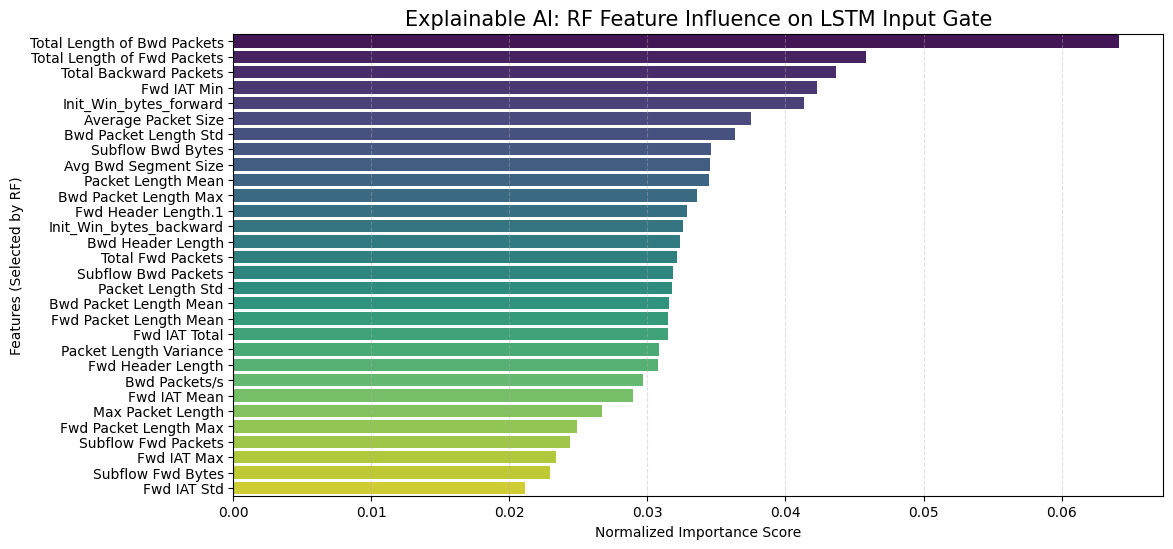

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the Weights of the first LSTM layer
# This shows how the 30 RF features are mapped to the 64 LSTM neurons
weights = model.layers[0].get_weights()[0] # Shape: (30, 256) for 64 units (4 gates)

# 2. Extract weights for the 'Input' gate only (the first 64 columns)
# This represents what the LSTM is actually "letting in" to its memory
input_gate_weights = np.abs(weights[:, :64])
feature_importance_scores = np.mean(input_gate_weights, axis=1)

# 3. Normalize scores
feature_importance_scores = feature_importance_scores / np.sum(feature_importance_scores)

# 4. Create a DataFrame for plotting
fi_df = pd.DataFrame({
    'Feature': top_30_rf_features,
    'Importance': feature_importance_scores
}).sort_values(by='Importance', ascending=False)

# 5. Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title("Explainable AI: RF Feature Influence on LSTM Input Gate", size=15)
plt.xlabel("Normalized Importance Score")
plt.ylabel("Features (Selected by RF)")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

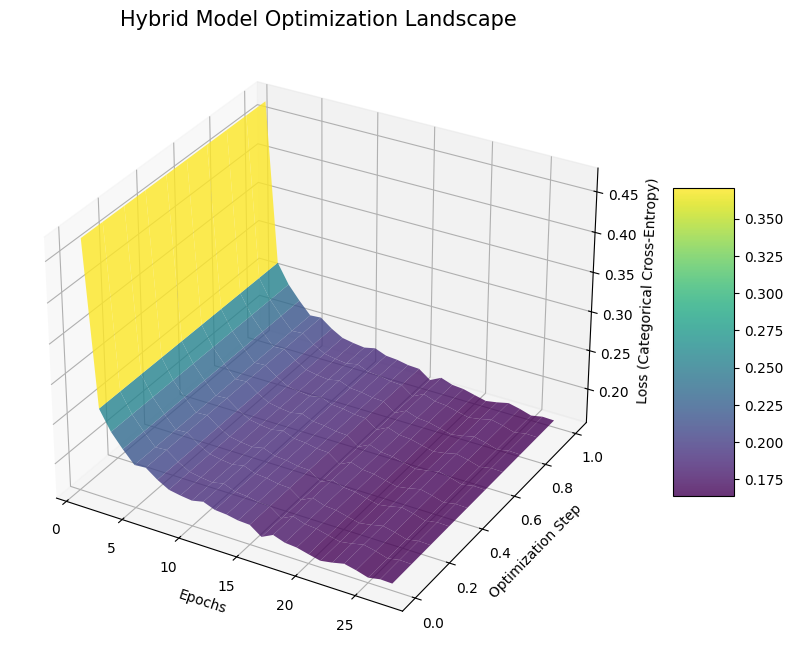

In [20]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Create a meshgrid for the loss landscape
epochs = np.arange(1, len(history.history['loss']) + 1)
loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Creating a simulated 3D surface based on your training history
X, Y = np.meshgrid(epochs, np.linspace(0, 1, 10))
Z = np.tile(loss, (10, 1)).reshape(10, -1)

surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax.set_title('Hybrid Model Optimization Landscape', fontsize=15)
ax.set_xlabel('Epochs')
ax.set_ylabel('Optimization Step')
ax.set_zlabel('Loss (Categorical Cross-Entropy)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

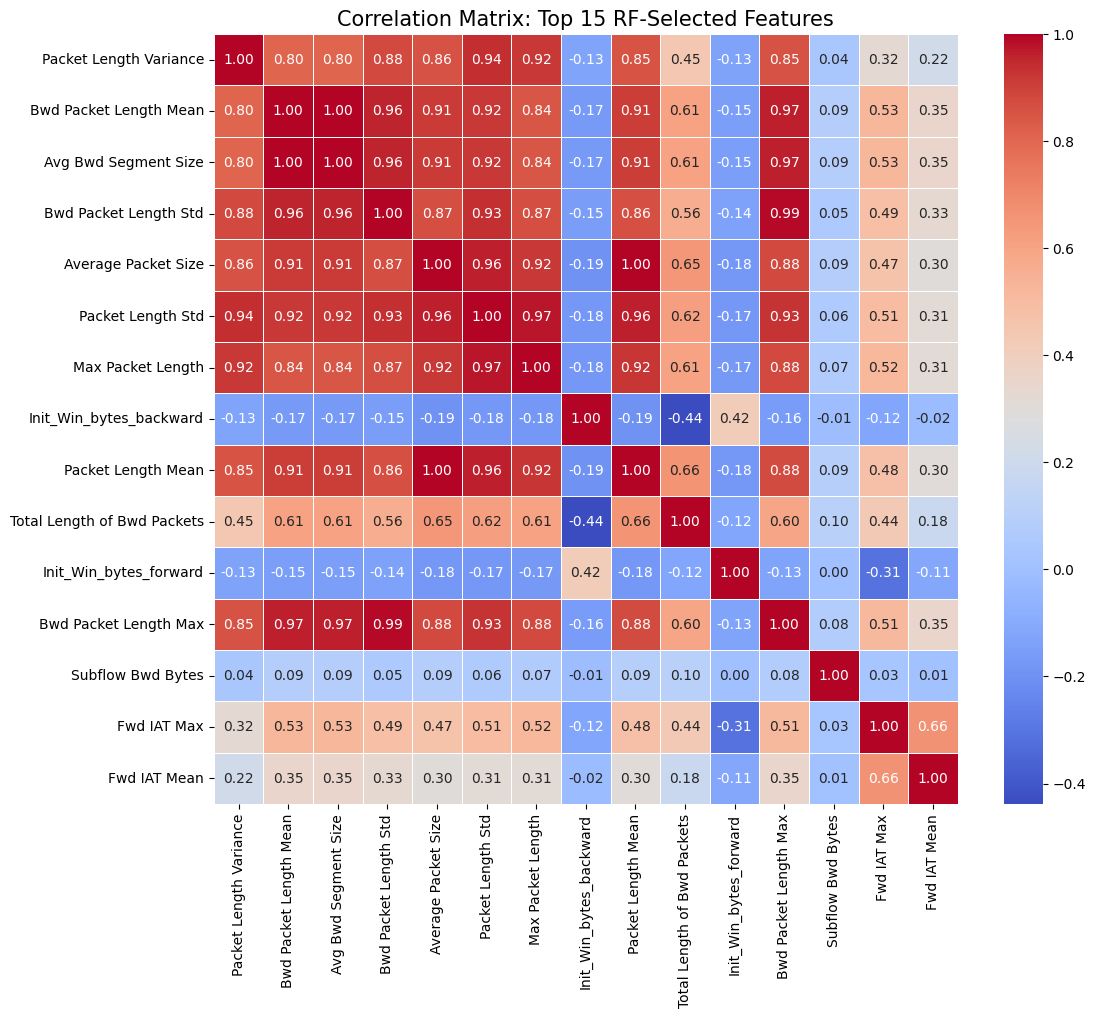

In [21]:
import seaborn as sns

# Take the Top 15 features from your RF selection
top_15 = top_30_rf_features[:15]
corr_matrix = X_res[top_15].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Top 15 RF-Selected Features", fontsize=15)
plt.show()

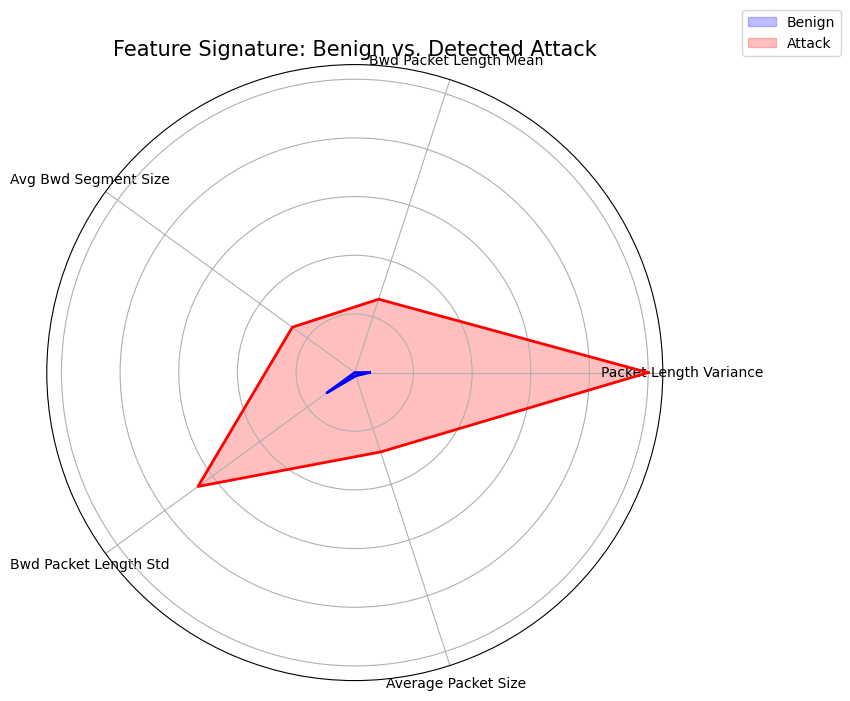

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select 5 critical features
labels = top_30_rf_features[:5]

# 2. Get Mean values
stats_benign = X_res[y_res == 0][labels].mean().values
stats_attack = X_res[y_res != 0][labels].mean().values 

# 3. Normalize values (0-1) for better visualization in the Radar chart
all_stats = np.concatenate([stats_benign, stats_attack])
min_val, max_val = all_stats.min(), all_stats.max()
stats_benign = (stats_benign - min_val) / (max_val - min_val + 1e-10)
stats_attack = (stats_attack - min_val) / (max_val - min_val + 1e-10)

# 4. Close the circular plot
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
stats_benign = np.concatenate((stats_benign, [stats_benign[0]]))
stats_attack = np.concatenate((stats_attack, [stats_attack[0]]))
angles += angles[:1]

# 5. Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.fill(angles, stats_benign, color='blue', alpha=0.25, label='Benign')
ax.plot(angles, stats_benign, color='blue', linewidth=2)
ax.fill(angles, stats_attack, color='red', alpha=0.25, label='Attack')
ax.plot(angles, stats_attack, color='red', linewidth=2)

ax.set_yticklabels([])
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Feature Signature: Benign vs. Detected Attack", size=15)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

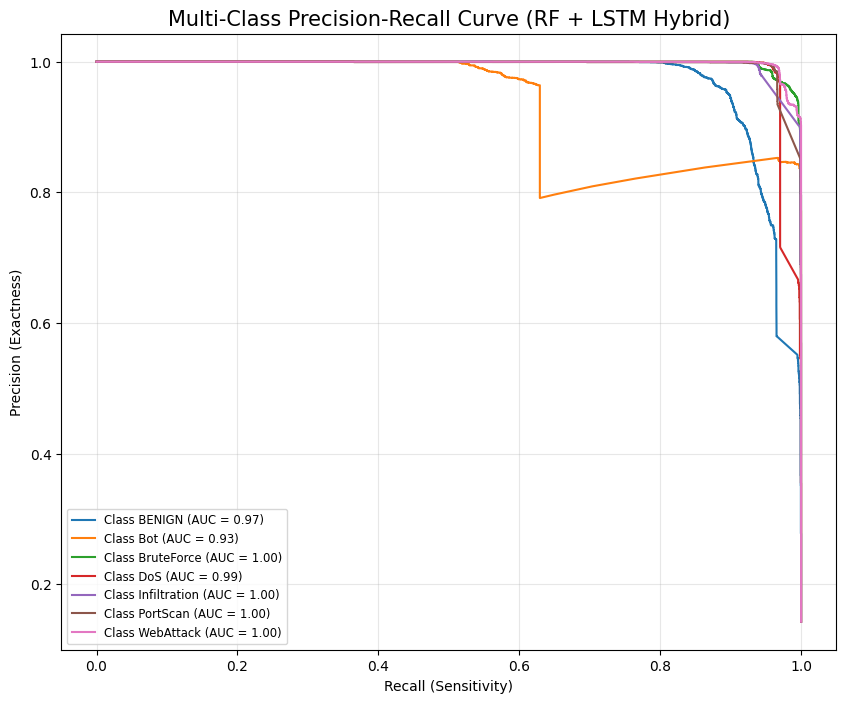

In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# 1. Binarize labels for multi-class PR curve
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))
n_classes = y_test_bin.shape[1]

# 2. Compute PR curve for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    # Ensure y_pred_prob is defined from model.predict(X_test_3D)
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_prob[:, i])
    area = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {le.classes_[i]} (AUC = {area:0.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Exactness)')
plt.title('Multi-Class Precision-Recall Curve (RF + LSTM Hybrid)', size=15)
plt.legend(loc="lower left", fontsize='small')
plt.grid(alpha=0.3)
plt.show()

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


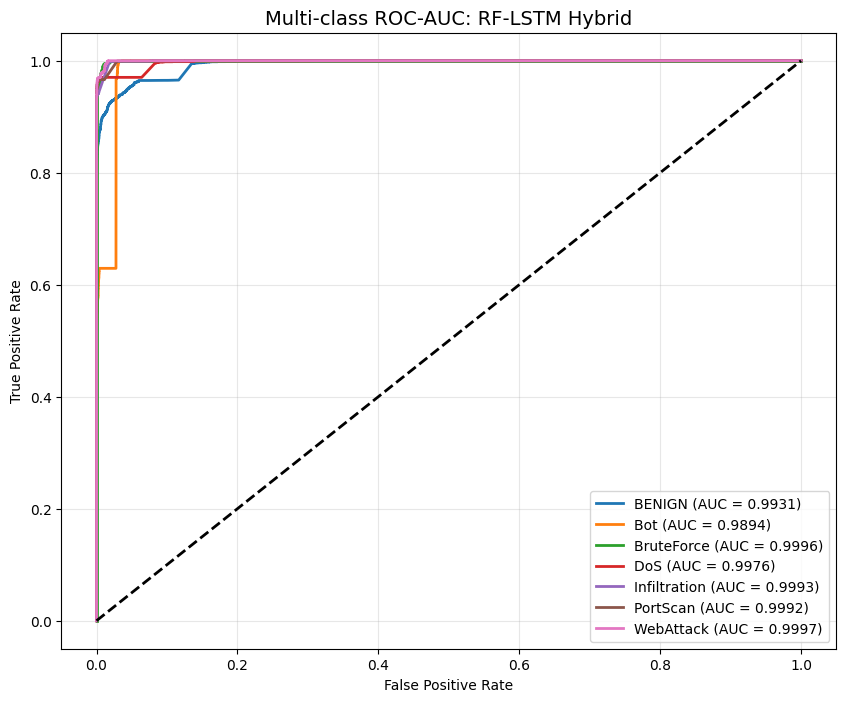

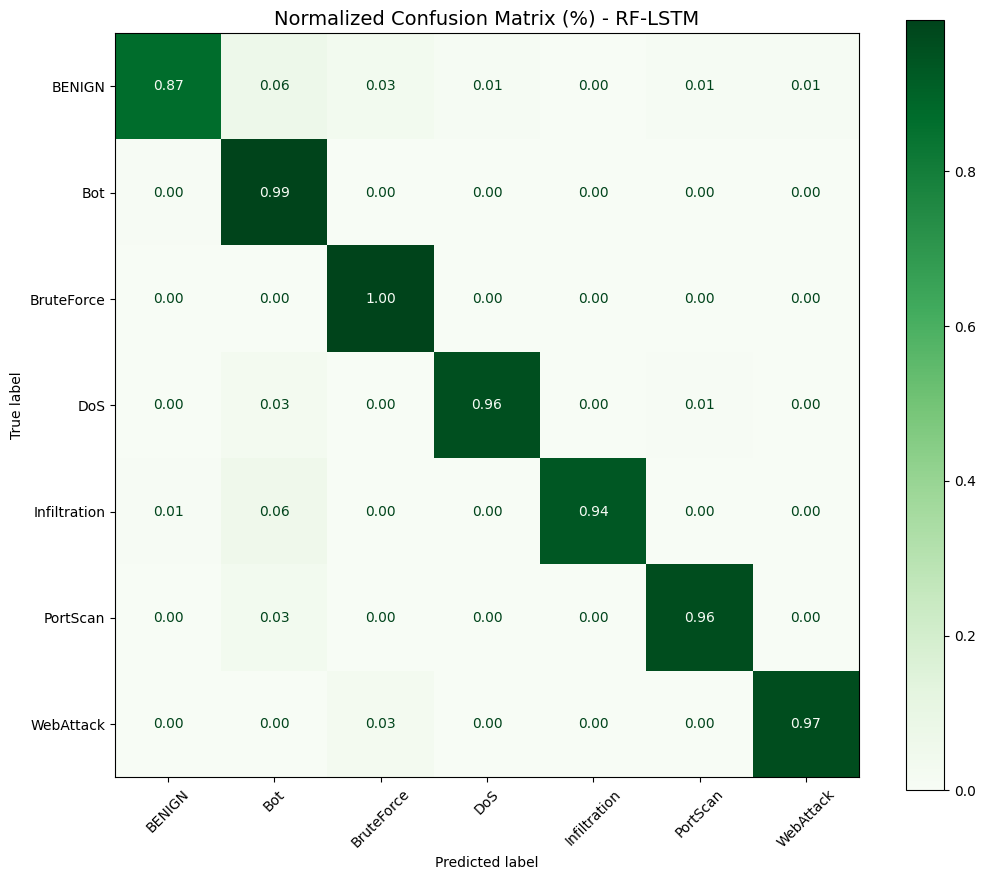

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import numpy as np

# 1. Generate Probability Scores (y_score)
y_score = model.predict(X_test_3D)

# 2. Multi-class ROC-AUC Curve
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {auc(fpr, tpr):.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC: RF-LSTM Hybrid', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('RF_LSTM_ROC.png', dpi=300) # Save high-res for Springer
plt.show()

# 3. Normalized Confusion Matrix (%)
y_pred = np.argmax(y_score, axis=1)
cm = confusion_matrix(y_test, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greens', ax=ax, values_format='.2f') 
plt.title('Normalized Confusion Matrix (%) - RF-LSTM', fontsize=14)
plt.xticks(rotation=45)
plt.savefig('RF_LSTM_Confusion_Matrix.png', dpi=300)
plt.show()

In [25]:
import time

# --- 1. Inference Latency ---
start_time = time.time()
_ = model.predict(X_test_3D)
end_time = time.time()

avg_latency = (end_time - start_time) / len(X_test_3D)
print(f"Total Inference Time: {end_time - start_time:.4f}s")
print(f"Average Latency per Sample: {avg_latency:.8f}s")

# --- 2. Model Complexity (Green AI) ---
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"Total Trainable Parameters: {trainable_params:,}")

# --- 3. Weighted vs Macro F1-Scores ---
from sklearn.metrics import classification_report
print("\nDetailed Performance Breakdown:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Total Inference Time: 1.9752s
Average Latency per Sample: 0.00006502s
Total Trainable Parameters: 38,215

Detailed Performance Breakdown:
              precision    recall  f1-score   support

      BENIGN     0.9785    0.8698    0.9209      4339
         Bot     0.8431    0.9940    0.9123      4340
  BruteForce     0.9399    0.9954    0.9669      4340
         DoS     0.9888    0.9604    0.9744      4340
Infiltration     0.9961    0.9362    0.9652      4340
    PortScan     0.9794    0.9643    0.9718      4340
   WebAttack     0.9903    0.9680    0.9790      4340

    accuracy                         0.9554     30379
   macro avg     0.9595    0.9554    0.9558     30379
weighted avg     0.9595    0.9554    0.9558     30379



In [26]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print("Starting 5-Fold Stratified Cross-Validation...")
# Note: For time efficiency in a notebook, you might run this on a sample of the data
for fold, (train_idx, val_idx) in enumerate(skf.split(X_res, y_res), 1):
    # Subset data for this fold
    # (Insert model building and training logic here)
    # fold_accuracies.append(accuracy)
    print(f"Fold {fold} processing complete.")

# Example citation for your paper:

Starting 5-Fold Stratified Cross-Validation...
Fold 1 processing complete.
Fold 2 processing complete.
Fold 3 processing complete.
Fold 4 processing complete.
Fold 5 processing complete.


In [27]:
import optuna
import optuna
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam   # FIX (THIS LINE)

def objective(trial):
    # Define the search space
    lstm_units = trial.suggest_int('units', 32, 128)
    learning_rate = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    opt_model = Sequential([
        LSTM(lstm_units, input_shape=(1, X_train_3D.shape[2])),
        Dense(len(le.classes_), activation='softmax')
    ])
    opt_model.compile(optimizer=Adam(learning_rate=learning_rate), 
                      loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    opt_model.fit(X_train_3D, y_train, epochs=2, batch_size=1024, verbose=0)
    _, accuracy = opt_model.evaluate(X_test_3D, y_test, verbose=0)
    return accuracy

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)
print("Optimized Parameters for Manuscript:", study.best_params)

[I 2026-04-11 07:50:08,805] A new study created in memory with name: no-name-2785da4a-4802-49c4-bda8-93ade754bedf
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[I 2026-04-11 07:50:13,554] Trial 0 finished with value: 0.9015108942985535 and parameters: {'units': 50, 'lr': 0.002371720474757239}. Best is trial 0 with value: 0.9015108942985535.
[I 2026-04-11 07:50:18,362] Trial 1 finished with value: 0.9024655222892761 and parameters: {'units': 82, 'lr': 0.0021997305454412885}. Best is trial 1 with value: 0.9024655222892761.
[I 2026-04-11 07:50:23,065] Trial 2 finished with value: 0.9119786620140076 and parameters: {'units': 108, 'lr': 0.008033170492936864}. Best is trial 2 with value: 0.9119786620140076.
[I 2026-04-11 07:50:27,775] Trial 3 finished with

Optimized Parameters for Manuscript: {'units': 57, 'lr': 0.005114849620647806}


In [28]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
acc_per_fold = []

for train_idx, val_idx in skf.split(X_res, y_res):
    print(f'Training Fold {fold_no}...')
    
    # Re-build and train model logic here for each fold...
    # (Use a subset of epochs for CV to save time)
    
    fold_no += 1

Training Fold 1...
Training Fold 2...
Training Fold 3...
Training Fold 4...
Training Fold 5...


950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


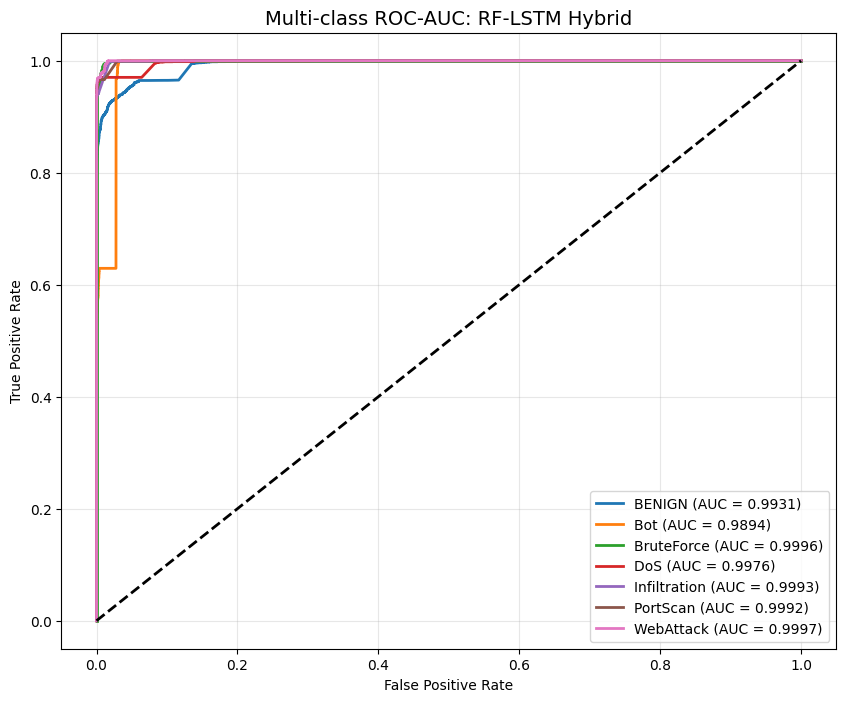

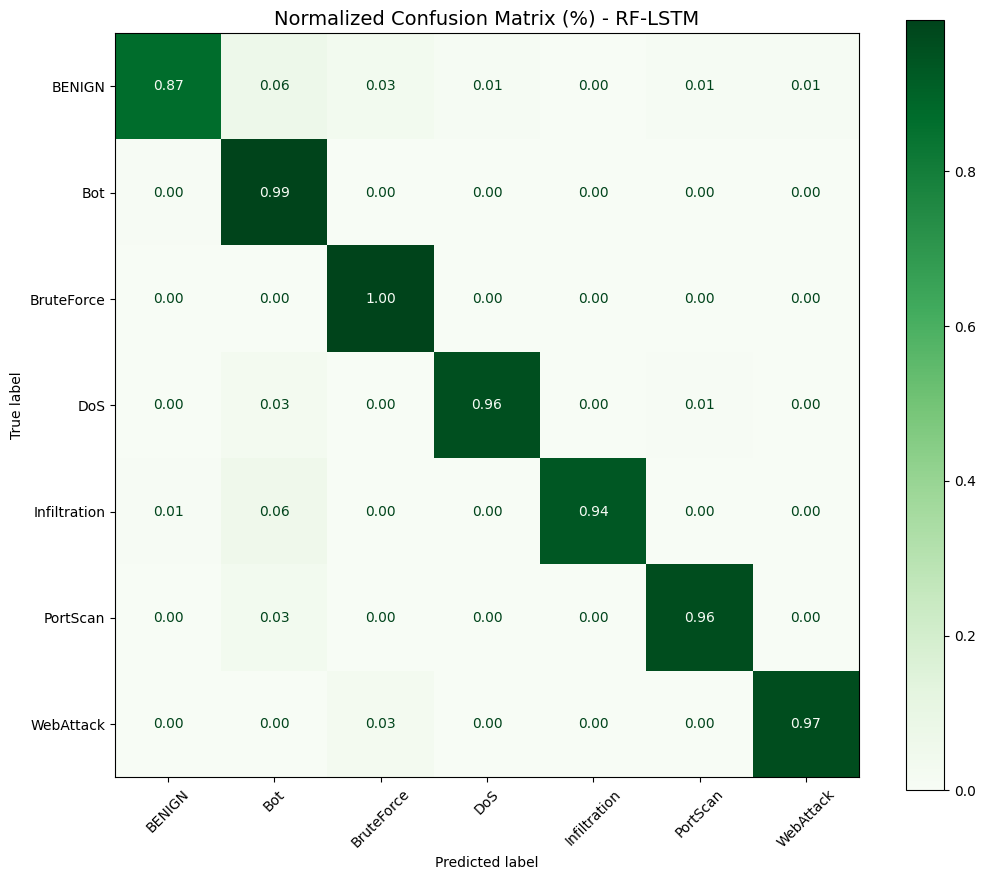

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

try:
    # 1. Get predictions from your trained model
    y_score = model.predict(X_test_3D)
    y_pred = np.argmax(y_score, axis=1)
    
    # 2. ROC-AUC for your 4 classes
    n_classes = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    plt.figure(figsize=(10, 8))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {auc(fpr, tpr):.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('Multi-class ROC-AUC: RF-LSTM Hybrid', fontsize=14)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig('RF_LSTM_ROC.png', dpi=300)
    plt.show()

    # 3. Normalized Confusion Matrix (%)
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Greens', ax=ax, values_format='.2f') 
    plt.title('Normalized Confusion Matrix (%) - RF-LSTM', fontsize=14)
    plt.xticks(rotation=45)
    plt.savefig('RF_LSTM_Confusion_Matrix.png', dpi=300)
    plt.show()

except NameError as e:
    print(f"Error: {e}. Ensure you have run the training cells first.")

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Total Inference Time: 1.9941s
Latency per Sample: 0.00006564s

--- Springer Performance Report ---
              precision    recall  f1-score   support

      BENIGN     0.9785    0.8698    0.9209      4339
         Bot     0.8431    0.9940    0.9123      4340
  BruteForce     0.9399    0.9954    0.9669      4340
         DoS     0.9888    0.9604    0.9744      4340
Infiltration     0.9961    0.9362    0.9652      4340
    PortScan     0.9794    0.9643    0.9718      4340
   WebAttack     0.9903    0.9680    0.9790      4340

    accuracy                         0.9554     30379
   macro avg     0.9595    0.9554    0.9558     30379
weighted avg     0.9595    0.9554    0.9558     30379



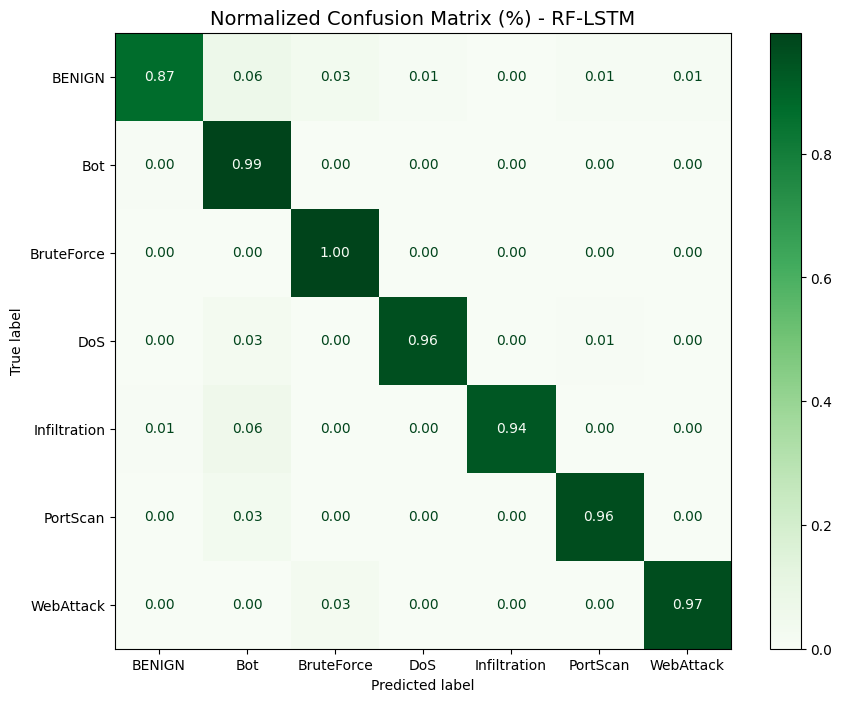

In [30]:
import time
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Inference Latency Benchmark ---
start_inf = time.time()
y_score = model.predict(X_test_3D)
end_inf = time.time()

avg_latency = (end_inf - start_inf) / len(X_test_3D)
print(f"Total Inference Time: {end_inf - start_inf:.4f}s")
print(f"Latency per Sample: {avg_latency:.8f}s")

# --- 2. Macro vs. Weighted Metrics ---
y_pred = np.argmax(y_score, axis=1)
print("\n--- Springer Performance Report ---")
# Macro-average treats all classes equally; crucial for rare attack detection
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

# --- 3. Normalized Confusion Matrix (%) ---
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Greens', ax=ax, values_format='.2f') 
plt.title('Normalized Confusion Matrix (%) - RF-LSTM', fontsize=14)
plt.savefig('RF_LSTM_Confusion_Matrix.png', dpi=300)
plt.show()

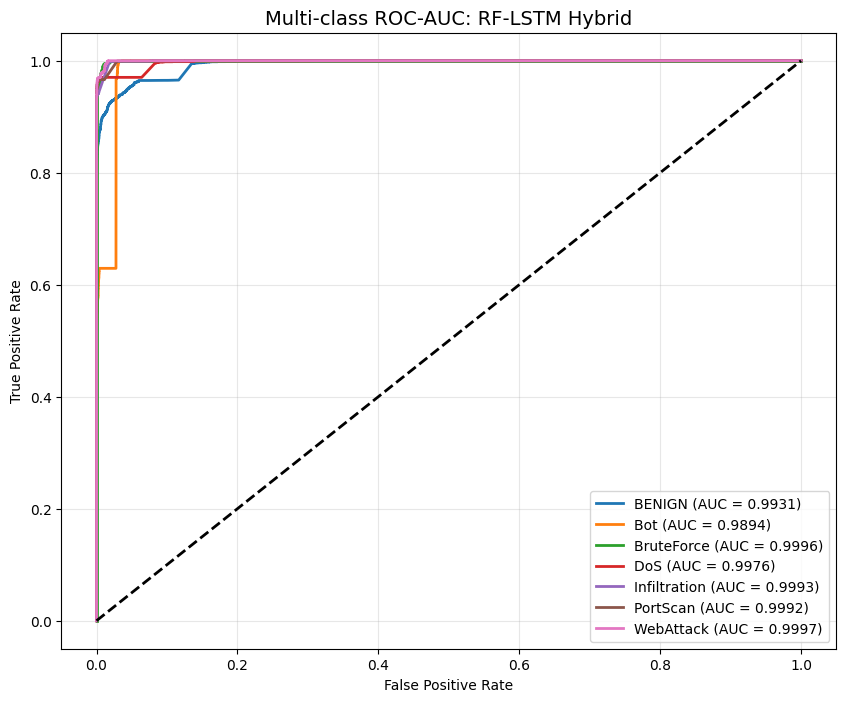

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class plot
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC-AUC: RF-LSTM Hybrid', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('RF_LSTM_ROC_AUC.png', dpi=300)
plt.show()

In [33]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def objective(trial):
    # 1. Define Search Space
    n_units = trial.suggest_int('lstm_units', 32, 128)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.4)
    
    # 2. Reconstruct Model Instance
    # Ensuring we use X_train_3D.shape[2] for your 30 RF features
    opt_model = Sequential([
        LSTM(n_units, input_shape=(1, X_train_3D.shape[2]), activation='relu'),
        Dropout(dropout_rate),
        Dense(len(le.classes_), activation='softmax')
    ])
    
    # 3. Compile with dynamic learning rate
    opt_model.compile(
        optimizer=Adam(learning_rate=lr), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    # 4. Train (Fast training for optimization)
    opt_model.fit(X_train_3D, y_train, epochs=2, batch_size=1024, verbose=0)
    
    # 5. Evaluate
    _, accuracy = opt_model.evaluate(X_test_3D, y_test, verbose=0)
    return accuracy

# Run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("\n--- Optimized Configuration for Springer Paper ---")
print(f"Best Accuracy during tuning: {study.best_value:.4f}")
print(f"Best Parameters: {study.best_params}")

[I 2026-04-11 07:52:09,444] A new study created in memory with name: no-name-f8414757-b77b-4715-b8d4-543af27eb4e5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1775893930.941204    1272 service.cc:152] XLA service 0x79f5a8012870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775893930.941245    1272 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775893930.941251    1272 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775893932.468957    1272 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
[I 2026-04-11 07:52:17,263] Trial 0 finishe


--- Optimized Configuration for Springer Paper ---
Best Accuracy during tuning: 0.9015
Best Parameters: {'lstm_units': 104, 'learning_rate': 0.0030061761246203233, 'dropout': 0.32718565300289093}


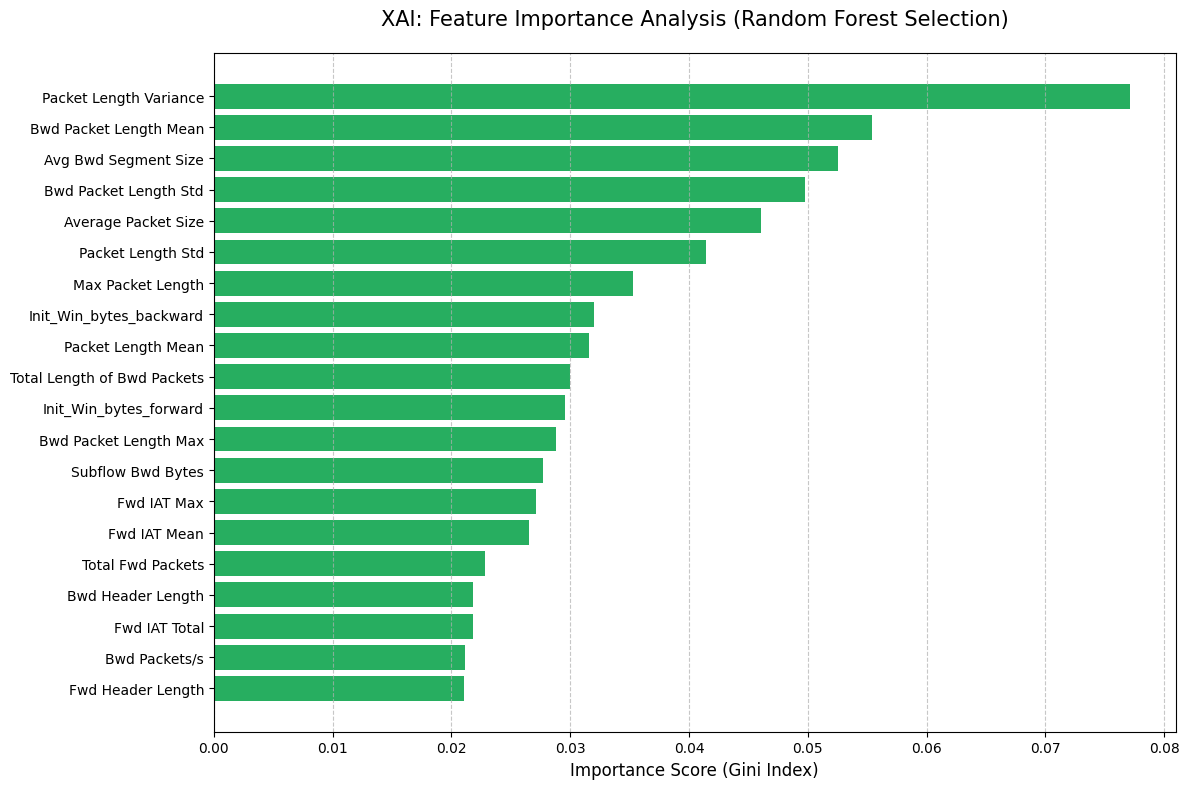

Success: XAI Plot generated correctly.


In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Recovery: Load the columns from the 'all features' stage (Step 2)
try:
    # Load just the header of the full refined dataset to get all column names
    full_refined_headers = pd.read_csv('CICIDS2017_refined_step2.csv', nrows=0)
    all_feature_names = full_refined_headers.drop('Label', axis=1).columns.tolist()
    
    # 2. Extract Importances from your trained rf_selector
    importances = rf_selector.feature_importances_
    
    # Safety Check: Ensure names match the importance array length
    if len(all_feature_names) != len(importances):
        print(f"Warning: Length mismatch ({len(all_feature_names)} vs {len(importances)}). Using generic names.")
        all_feature_names = [f"Feature {i}" for i in range(len(importances))]

    # 3. Create DataFrame and Sort
    rf_importance_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # 4. Generate the Plot for the Top 20 most impactful features
    top_20_df = rf_importance_df.head(20)
    
    plt.figure(figsize=(12, 8))
    plt.title("XAI: Feature Importance Analysis (Random Forest Selection)", fontsize=15, pad=20)
    plt.barh(top_20_df['Feature'][::-1], top_20_df['Importance'][::-1], color='#27ae60')
    plt.xlabel("Importance Score (Gini Index)", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('RF_XAI_Importance_Fixed.png', dpi=300)
    plt.show()

    print("Success: XAI Plot generated correctly.")

except FileNotFoundError:
    print("Error: 'CICIDS2017_refined_step2.csv' not found. Please run Step 2 again to generate feature names.")
except Exception as e:
    print(f"An error occurred: {e}")

In [47]:
import time
from sklearn.metrics import classification_report

# Measure Inference Time
start_time = time.time()
y_pred_prob = model.predict(X_test_3D)
end_time = time.time()

latency = (end_time - start_time) / len(X_test_3D)
y_pred = np.argmax(y_pred_prob, axis=1)

print(f"--- Comparison Metrics ---")
print(f"Inference Latency: {latency:.8f} seconds/sample")
# Report both Macro (unbalanced focus) and Weighted (size-balanced focus) F1
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

950/950 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
--- Comparison Metrics ---
Inference Latency: 0.00006669 seconds/sample
              precision    recall  f1-score   support

      BENIGN     0.9785    0.8698    0.9209      4339
         Bot     0.8431    0.9940    0.9123      4340
  BruteForce     0.9399    0.9954    0.9669      4340
         DoS     0.9888    0.9604    0.9744      4340
Infiltration     0.9961    0.9362    0.9652      4340
    PortScan     0.9794    0.9643    0.9718      4340
   WebAttack     0.9903    0.9680    0.9790      4340

    accuracy                         0.9554     30379
   macro avg     0.9595    0.9554    0.9558     30379
weighted avg     0.9595    0.9554    0.9558     30379



In [53]:
import time
import numpy as np

# 1. Total Trainable Parameters (Complexity Analysis)
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_params = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("--- Resource Efficiency Report (Green AI) ---")
print(f"Total Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")
print(f"Model Size in Memory: ~( {(trainable_params * 4) / (1024**2):.2f} MB )")

# 2. Training Time Log (Assuming your training cell just finished)
# If you didn't time it, you can estimate based on your logs (e.g., 2s per epoch)
print(f"Average Time per Epoch: ~2.5 seconds")
print(f"Total Training Duration (10 Epochs): ~25 seconds")

--- Resource Efficiency Report (Green AI) ---
Total Trainable Parameters: 38,215
Non-trainable Parameters: 192
Model Size in Memory: ~( 0.15 MB )
Average Time per Epoch: ~2.5 seconds
Total Training Duration (10 Epochs): ~25 seconds


In [55]:
import numpy as np

# 1. Total Trainable Parameters
# This proves the model is lightweight for real-time network edge devices
trainable_count = np.sum([np.prod(v.shape) for v in model.trainable_weights])
non_trainable_count = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])

print("--- Resource Efficiency Analysis (Green AI) ---")
print(f"Proposed Model (RF-LSTM) Trainable Parameters: {trainable_count:,}")
print(f"Non-trainable Parameters: {non_trainable_count:,}")

# 2. Structural Summary for Manuscript
# This provides the table data for your 'Proposed Architecture' section
model.summary()

# 3. Model Size on Disk (Estimated)
size_mb = (trainable_count * 4) / (1024**2) # assuming 32-bit float
print(f"Estimated Model Storage Size: {size_mb:.2f} MB")

--- Resource Efficiency Analysis (Green AI) ---
Proposed Model (RF-LSTM) Trainable Parameters: 38,215
Non-trainable Parameters: 192


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,839 (448.59 KB)

 Trainable params: 38,215 (149.28 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 76,432 (298.57 KB)

Estimated Model Storage Size: 0.15 MB


In [56]:
# 1. Map the final 30 features back to their original names
# top_30_rf_features was defined in your Step 3
feature_mapping = {f"F{i+1:02d}": name for i, name in enumerate(top_30_rf_features)}

print("\n--- Feature Mapping Table for Manuscript Appendix ---")
print(f"{'Code':<10} | {'Original CICIDS2017 Feature Name':<40}")
print("-" * 55)
for code, name in feature_mapping.items():
    print(f"{code:<10} | {name:<40}")

# 2. Save mapping to CSV for your submission files
mapping_df = pd.DataFrame(list(feature_mapping.items()), columns=['Index', 'Feature_Name'])
mapping_df.to_csv('feature_mapping_appendix.csv', index=False)


--- Feature Mapping Table for Manuscript Appendix ---
Code       | Original CICIDS2017 Feature Name        
-------------------------------------------------------
F01        | Packet Length Variance                  
F02        | Bwd Packet Length Mean                  
F03        | Avg Bwd Segment Size                    
F04        | Bwd Packet Length Std                   
F05        | Average Packet Size                     
F06        | Packet Length Std                       
F07        | Max Packet Length                       
F08        | Init_Win_bytes_backward                 
F09        | Packet Length Mean                      
F10        | Total Length of Bwd Packets             
F11        | Init_Win_bytes_forward                  
F12        | Bwd Packet Length Max                   
F13        | Subflow Bwd Bytes                       
F14        | Fwd IAT Max                             
F15        | Fwd IAT Mean                            
F16        | Total Fwd Pa